# Behavior Classification: CNN + LSTM (Local Version - Fixed)

Pipeline ini dioptimasi untuk berjalan di lingkungan lokal dengan semua library yang diperlukan.

---

### 1. Import Libraries & Konfigurasi Path

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow Version: {tf.__version__}")

# 1. KONFIGURASI PATH
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
MODEL_PATH = os.path.join(BASE_PATH, 'models')

print("-" * 50)
print("🔍 SYSTEM AUDIT & DATA PREPARATION (LOCAL)")
print("-" * 50)

# 2. VERIFIKASI FILE
if os.path.exists(DATA_PATH):
    npy_files = glob.glob(os.path.join(DATA_PATH, "*.npy"))
    print(f"📂 Scanning Directory: {DATA_PATH}")
    print(f"✨ Found {len(npy_files)} data files (.npy)")
else:
    print(f"❌ ERROR: Folder data {DATA_PATH} tidak ditemukan!")

# 3. PREPARASI MODEL FOLDER
os.makedirs(MODEL_PATH, exist_ok=True)
print(f"💾 Model Save Path: {MODEL_PATH}")

TensorFlow Version: 2.21.0
--------------------------------------------------
🔍 SYSTEM AUDIT & DATA PREPARATION (LOCAL)
--------------------------------------------------
📂 Scanning Directory: d:\Arya Files\kuliah\UNM_SEM6\COMVIS\Project Akhir\data\processed_holistic
✨ Found 2 data files (.npy)
💾 Model Save Path: d:\Arya Files\kuliah\UNM_SEM6\COMVIS\Project Akhir\models


### 2. Load & Split Data

In [26]:
X = np.load(os.path.join(DATA_PATH, 'X.npy'))
y = np.load(os.path.join(DATA_PATH, 'y.npy'))

behavior_names = ["Layar", "Materi", "Tulis", "Ponsel", "Menoleh", "Tidur"]
FEATURE_COUNT = X.shape[2]

print(f"✅ Data Loaded: X={X.shape}, y={y.shape}")
print(f"ℹ️ Detected Features: {FEATURE_COUNT}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"📊 Split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

✅ Data Loaded: X=(1828, 45, 273), y=(1828,)
ℹ️ Detected Features: 273
📊 Split: Train=1279, Val=274, Test=275


### 3. Build & Train Model

In [27]:
model = Sequential([
    Input(shape=(45, FEATURE_COUNT)),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(6)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

checkpoint_path = os.path.join(MODEL_PATH, 'pose_model_holistic_local.keras')
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("🚀 Starting Training...")
history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), 
    epochs=150, batch_size=32, callbacks=callbacks
)

🚀 Starting Training...
Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2778 - loss: 1.7283
Epoch 1: val_accuracy improved from None to 0.21533, saving model to d:\Arya Files\kuliah\UNM_SEM6\COMVIS\Project Akhir\models\pose_model_holistic_local.keras

Epoch 1: finished saving model to d:\Arya Files\kuliah\UNM_SEM6\COMVIS\Project Akhir\models\pose_model_holistic_local.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.2940 - loss: 1.6989 - val_accuracy: 0.2153 - val_loss: 1.7527 - learning_rate: 5.0000e-04
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3926 - loss: 1.5866
Epoch 2: val_accuracy improved from 0.21533 to 0.29927, saving model to d:\Arya Files\kuliah\UNM_SEM6\COMVIS\Project Akhir\models\pose_model_holistic_local.keras

Epoch 2: finished saving model to d:\Arya Files\kuliah\UNM_SEM6\COMVIS\Project Akhir\models\pose_model_holistic_local.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4206 - loss: 1.5381 - val_accuracy: 

### 4. Evaluasi & Visualisasi

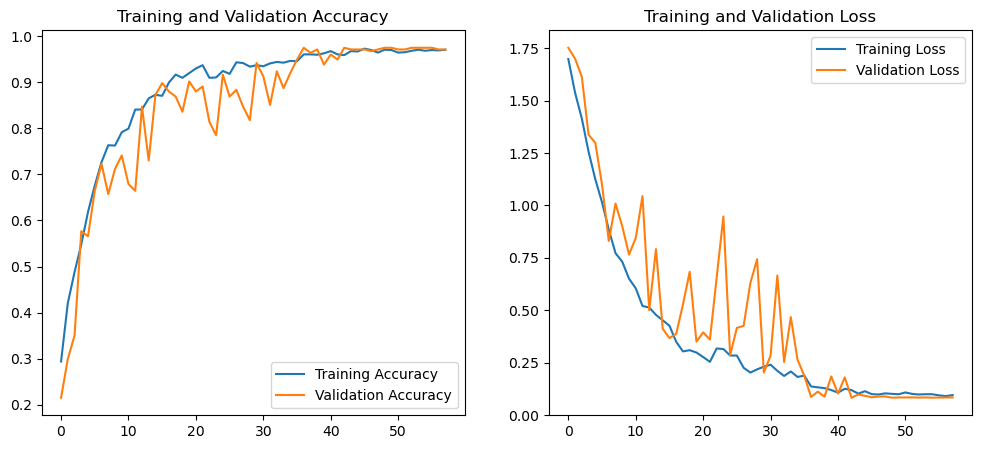

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

--- Classification Report ---
              precision    recall  f1-score   support

       Layar       1.00      1.00      1.00        48
      Materi       1.00      0.96      0.98        47
       Tulis       1.00      0.91      0.95        45
      Ponsel       1.00      0.93      0.96        43
     Menoleh       1.00      0.93      0.97        46
       Tidur       0.79      1.00      0.88        46

    accuracy                           0.96       275
   macro avg       0.97      0.96      0.96       275
weighted avg       0.97      0.96      0.96       275



In [28]:
# Plot Accuracy & Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

# Classification Report
y_pred_logits = model.predict(X_test)
y_pred = np.argmax(y_pred_logits, axis=1)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=behavior_names))

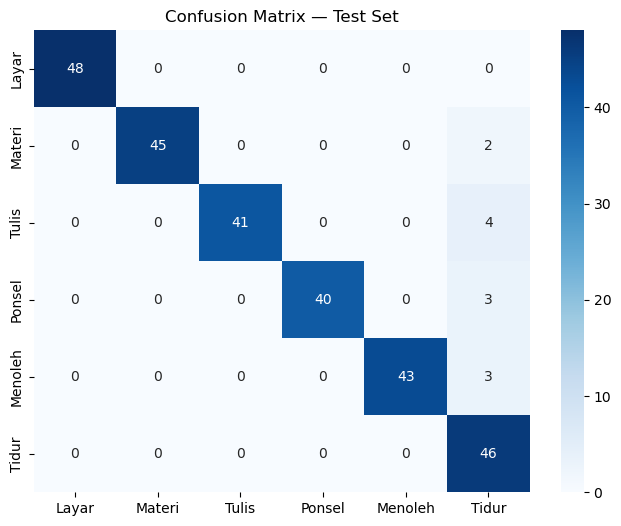

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=behavior_names,
            yticklabels=behavior_names)
plt.title('Confusion Matrix — Test Set')
plt.show()